# 04 · Compare cumulative flux across the time-lag scenarios

How much does the time-lag setting alone change the overall flux budget? Each
analyzer's raw data is processed under five scenarios, varying only how the
N2O / CH4 time lag is found (see [processing versions](../docs/processing-versions.md)):

- `*-1` open covariance maximization (0 to 10 s, no default)
- `*-2` covariance maximization with a default fallback
- `*-3` covariance maximization over a narrow window with a default fallback
- `*-4` constant lag
- `*-5` PWB (lag detected and removed from the raw data before flux processing)

Everything else (site, period, raw signal, all other EddyPro settings) is held
fixed, so any difference in the resulting flux is attributable to the lag
setting. This notebook tracks the cumulative flux (the running budget) per
scenario, the most direct picture of how the lag choice shifts the total flux.
All five scenarios, `*-1` through `*-5`, carry flux and enter the comparison.

## What makes the comparison fair

- **Paired by half-hour.** The scenarios share the same raw data, so the
  comparison is paired: for every timestamp the fluxes differ only in the lag. We
  treat them as matched pairs, not as independent samples.
- **Common samples only.** A scenario can fail to return a flux for a given
  half-hour (for example the open search `*-1` finding no clear covariance
  maximum). Comparing scenarios over different sets of half-hours would confound
  the lag effect with differing coverage, so we keep only the half-hours where
  **every** scenario produced a finite flux. The cumulative budget is computed on
  this common set, so all scenarios see exactly the same timestamps.
- **Within analyzer only.** QCL (2021_1) and LGR (2021_2) are different
  campaigns covering different periods. Each analyzer is compared on its own; QCL
  and LGR half-hours are never pooled.

A note on what is *not* filtered: we keep every half-hour where all fluxes exist,
with no extra quality-flag screen (the flags are not in the column subsets). A
stricter comparison could apply the same QC filter to all scenarios; that would
change the absolute numbers but not the paired logic.

## Imports

In [1]:
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

In [2]:
# Inputs: the per-scenario flux column subsets from notebook 02. All five
# scenarios (*-1 through *-5) carry fluxes; the PWB scenario (*-5) is appended
# below via an existence check so the notebook still runs if its subset is absent.
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Analysis year (the subsets are already restricted to 2021 in notebook 02).
YEAR = 2021

# The time-lag scenarios per analyzer. QCL (campaign 2021_1) and LGR (campaign
# 2021_2) cover different periods, so each analyzer is compared on its own; we
# never mix QCL and LGR half-hours. The PWB scenario (*-5) is appended below if
# its flux subset is present.
ANALYZERS = {
    "QCL": ["QCL-1", "QCL-2", "QCL-3", "QCL-4"],
    "LGR": ["LGR-1", "LGR-2", "LGR-3", "LGR-4"],
}
for analyzer, codes in ANALYZERS.items():
    pwb = f"{analyzer}-5"
    if (SUBSETDIR / f"{pwb}.parquet").exists():
        codes.append(pwb)

# Fluxes to compare, per gas.
GASES = {"N2O": "FN2O", "CH4": "FCH4"}

# Load the flux subsets per analyzer, restricted to YEAR.
data = {}
for codes in ANALYZERS.values():
    for code in codes:
        df = load_parquet(filepath=str(SUBSETDIR / f"{code}.parquet"))
        data[code] = df.loc[df.index.year == YEAR]
        print(f"{code}: {data[code].shape[0]} rows")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.080 seconds).

QCL-1: 9632 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-2.parquet (0.003 seconds).

QCL-2: 9632 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-3.parquet (0.003 seconds).

...

LGR-3: 7803 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-4.parquet (0.002 seconds).

LGR-4: 7803 rows


> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-5.parquet (0.002 seconds).

LGR-5: 7803 rows


## Build the paired, common-sample sets

For each analyzer and gas, line up the one gas flux across the scenarios on the
timestamp index and keep only the half-hours where every scenario has a finite
value. This common set is the fair comparison set used for the cumulative budget.

In [3]:
def paired_common(codes, fluxvar):
    # Align one gas flux across the scenarios and keep only timestamps where every
    # scenario has a finite flux (the fair, paired comparison set).
    frame = pd.DataFrame({code: data[code][fluxvar] for code in codes})
    common = frame.dropna(how="any")
    return frame, common


common_sets = {}
for analyzer, codes in ANALYZERS.items():
    for gas, fluxvar in GASES.items():
        frame, common = paired_common(codes, fluxvar)
        common_sets[(analyzer, gas)] = common
        print(f"\n=== {analyzer} {gas} ({fluxvar}) ===")
        for code in codes:
            print(f"  {code}: {int(frame[code].notna().sum())} valid")
        print(f"  common to all {len(codes)}: {common.shape[0]} "
              f"({100 * common.shape[0] / frame.shape[0]:.1f}% of {frame.shape[0]} timestamps)")


=== QCL N2O (FN2O) ===
  QCL-1: 9452 valid
  QCL-2: 9452 valid
  QCL-3: 9452 valid
  QCL-4: 9452 valid
  QCL-5: 9455 valid
  common to all 5: 9451 (98.1% of 9632 timestamps)

=== QCL CH4 (FCH4) ===
  QCL-1: 9452 valid
  QCL-2: 9452 valid
  QCL-3: 9452 valid
  QCL-4: 9452 valid
  QCL-5: 9455 valid
  common to all 5: 9451 (98.1% of 9632 timestamps)

=== LGR N2O (FN2O) ===
  LGR-1: 7729 valid
  LGR-2: 7729 valid
  LGR-3: 7729 valid
  LGR-4: 7729 valid
  LGR-5: 7727 valid
  common to all 5: 7727 (99.0% of 7803 timestamps)

=== LGR CH4 (FCH4) ===
  LGR-1: 7729 valid
  LGR-2: 7729 valid
  LGR-3: 7729 valid
  LGR-4: 7729 valid
  LGR-5: 7727 valid
  common to all 5: 7727 (99.0% of 7803 timestamps)


## Cumulative flux (overall budget): all, daytime, nighttime

The running sum of the flux over the common samples, one line per scenario, in
three panels: all common half-hours, daytime only (`SW_IN_POT > 0`), and
nighttime only (`SW_IN_POT == 0`). Lines that fan apart over time mean the choice
of lag accumulates into a different total budget; splitting by day and night
shows whether that divergence is driven by the high-flux daytime or the low-flux
nighttime periods. `SW_IN_POT` (potential shortwave radiation) is carried in the
column subsets from notebook 02 and is identical across scenarios, so one day /
night mask applies to all of them.

Saved ..\figures\04_cumulative_qcl_n2o.png


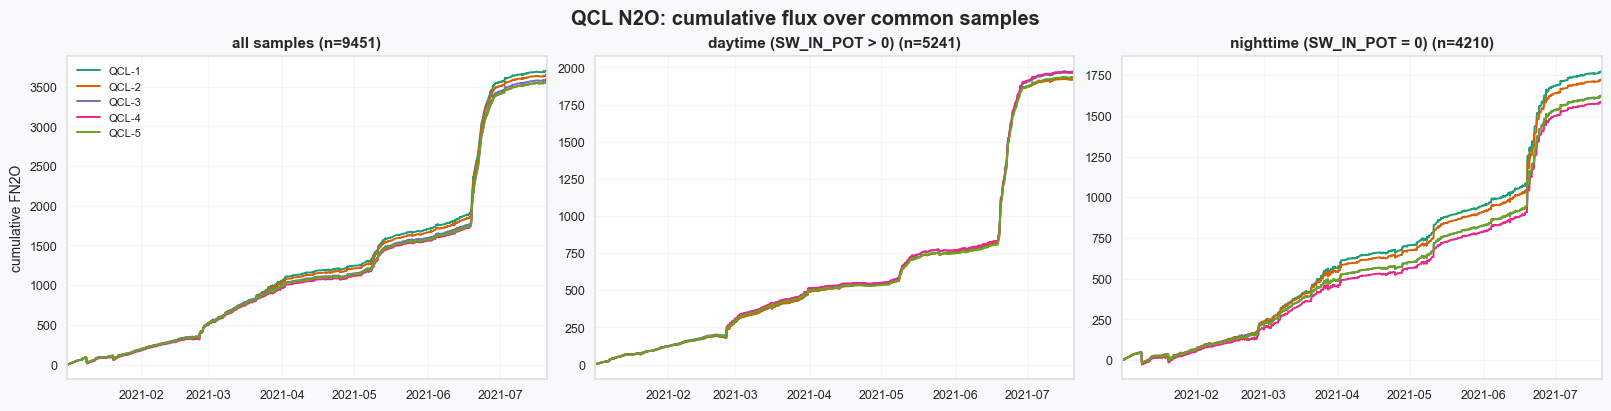

Saved ..\figures\04_cumulative_qcl_ch4.png


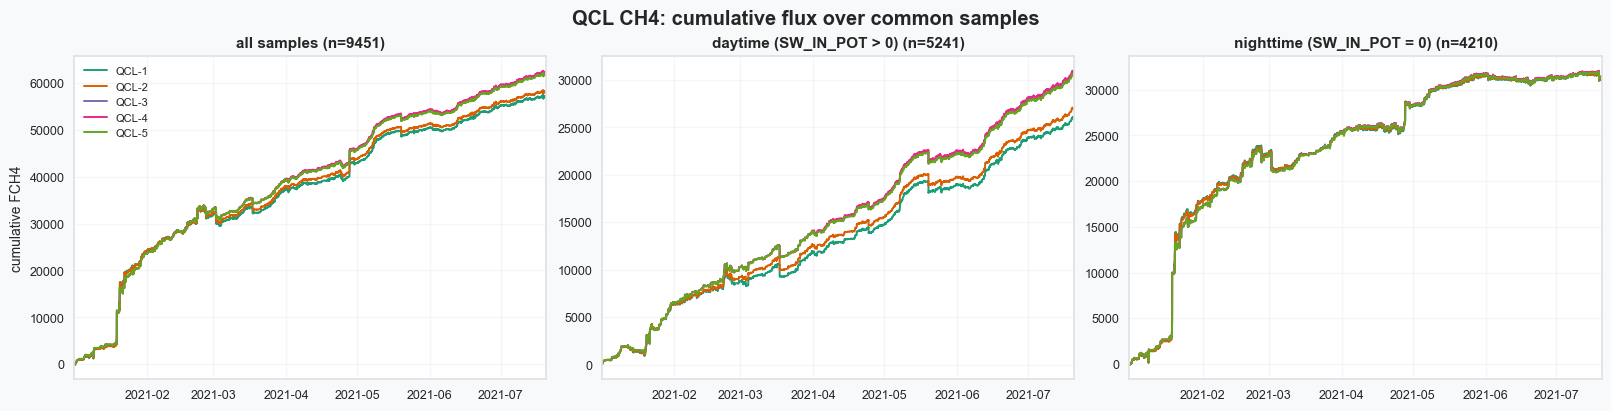

Saved ..\figures\04_cumulative_lgr_n2o.png


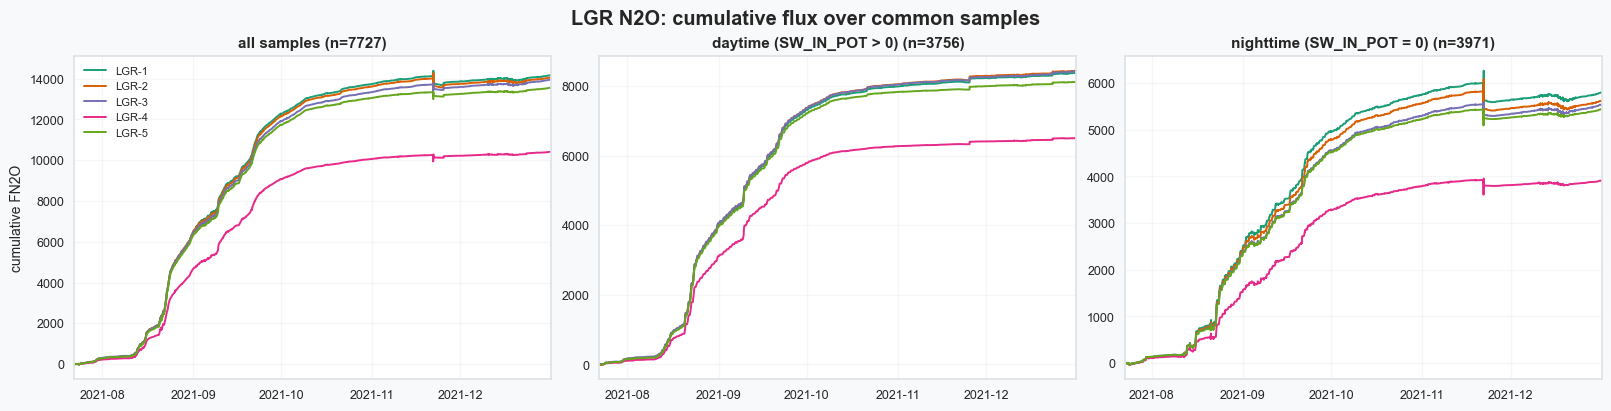

Saved ..\figures\04_cumulative_lgr_ch4.png


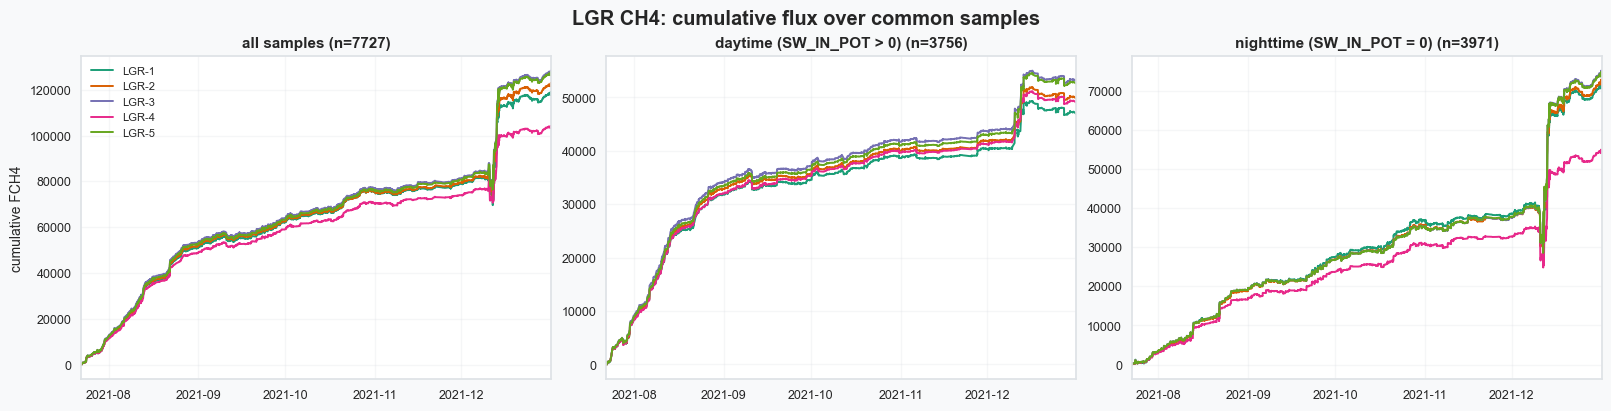

In [4]:
# Distinct color per scenario suffix.
VAR_COLORS = {"-1": "#1b9e77", "-2": "#d95f02", "-3": "#7570b3", "-4": "#e7298a", "-5": "#66a61e"}


def draw_cumulative(ax, frame, codes, title):
    """Plot the running sum of each scenario's flux on `ax`."""
    cum = frame.cumsum()
    for code in codes:
        suffix = "-" + code.split("-", 1)[1]
        ax.plot(cum.index, cum[code], lw=1.4, color=VAR_COLORS.get(suffix), label=code)
    if len(cum.index):
        ax.set_xlim(cum.index.min(), cum.index.max())
    ax.set_title(f"{title} (n={frame.shape[0]})", fontweight="bold")
    ax.grid(True, alpha=0.3)


for analyzer, codes in ANALYZERS.items():
    # SW_IN_POT is identical across scenarios; take it from the first one.
    swin = data[codes[0]]["SW_IN_POT"]
    for gas, fluxvar in GASES.items():
        common = common_sets[(analyzer, gas)]
        sw = swin.reindex(common.index)
        # Daytime = potential radiation above zero, nighttime = exactly zero.
        # (Half-hours with a missing SW_IN_POT fall into neither split.)
        panels = [
            ("all samples", common),
            ("daytime (SW_IN_POT > 0)", common[sw > 0]),
            ("nighttime (SW_IN_POT = 0)", common[sw == 0]),
        ]
        fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
        for ax, (title, frame) in zip(axes, panels):
            draw_cumulative(ax, frame, codes, title)
        axes[0].set_ylabel(f"cumulative {fluxvar}")
        axes[0].legend(fontsize=8)
        fig.suptitle(f"{analyzer} {gas}: cumulative flux over common samples",
                     fontweight="bold")
        out = FIGDIR / f"04_cumulative_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [5]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-23 10:16:30
End:      2026-06-23 10:16:32
Runtime:  0:00:02.628548
